# Learning Rate Schedulers

The learning rate ($\lambda$) is a hyperparameter that determines how big of a step should be taken at each iteration when updating the model's parameters when training the model. 

$$
W_{i+1} = W_{i} - \lambda * \frac{\partial L}{\partial W}
$$

LR schedulers, also known as LR decay or LR annealing, are techniques used to adjust the learning rate durnig the training process of a deep learning model. Instead of using a fixed LR throughout the entire training duration, LR schedulers modify the LR dynamically based on predefined rules or heuristics.

LR Schedulers offer a systematic way to change the learning rate, rather than manually tuning it. They're a crucial part of the traning process for many deep learning models. 

Here are a few reasons why LR Schedulers are important:

1. **Better Generalisation**: In the early stages of training, a large LR accelerates learning by allowing the model to quickly coverage towards good regions of the parameter space. However, once the model gets closer to the optimal solution, large updates can cause the model to oscillate around the minimum or even diverge. Reducing the learning rate over time can help the model to fine-tune its parameters and achieve better generalisation performance. 
1. **Faster Convergence**:  Initially, when the weights are random, it might be far from the optimal solution. Hence, a larger LR can help to make faster progress. As the model gets closer to the optimal solution, it needs to take smaller steps. Thus, reducing the LR can help the model converge faster. 
1. **Escaping Saddle Points and Local Minima**: At certain points during training, the model might get stuck in suboptimal local minima or saddle points. By periodically increasing the LR (as in cyclic LR Schedulers or the "warm restarts" of the CosineAnnealingWarmRestarts scheduler), the model can potentially escape these situations and find better solutions. 

In [1]:
import os
import gc
import random
from dataclasses import dataclass
from typing import Tuple
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchinfo import summary
from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy

from torchvision import datasets, transforms

In [2]:
def seed_everything(seed_value: int = 3):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed=seed_value)
    torch.cuda.manual_seed_all(seed=seed_value)
    torch.mps.manual_seed(seed=seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
def get_default_device() -> Tuple[torch.device, bool]:
    is_gpu_available = torch.cuda.is_available()
    return torch.device("cuda" if is_gpu_available else "cpu"), is_gpu_available

## Training and Dataset Configs

In [4]:
@dataclass(frozen=True)
class DatasetConfig:
    IMG_HEIGHT: int = 32
    IMG_WIDTH: int = 32
    IMG_CHANNELS: int = 1
    NUM_CLASSES: int = 10
    MEAN: tuple = (0.2860,)
    STD: tuple = (0.3530,)
    DATA_ROOT: str = "data"


@dataclass(frozen=True)
class TrainingConfig:
    BATCH_SIZE: int = 128
    NUM_EPOCHS: int = 61
    LEARNING_RATE: float = 0.1
    NUM_WORKERS: int = os.cpu_count()

## Datasets

In [5]:
def get_data(
    resize_dimensions: Tuple,
    batch_size: int,
    dataset_mean: tuple,
    dataset_std: tuple,
    pin_memory: bool = False,
    data_root: str = "data",
    num_workers: int = 0,
) -> Tuple[DataLoader, DataLoader]:
    preprocessing_transforms = transforms.Compose(
        [
            transforms.Resize(size=resize_dimensions),
            transforms.ToTensor(),
            transforms.Normalize(mean=dataset_mean, std=dataset_std),
        ]
    )

    train_dataloader = DataLoader(
        dataset=datasets.FashionMNIST(
            root=data_root,
            train=False,
            transform=preprocessing_transforms,
            download=True,
        ),
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    valid_dataloader = DataLoader(
        dataset=datasets.FashionMNIST(
            root=data_root,
            train=False,
            download=True,
            transform=preprocessing_transforms,
        ),
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    return train_dataloader, valid_dataloader

In [6]:
def denormalise(tensors, *, mean, std) -> torch.Tensor:
    """
    Denormalises the image tensors using mean and std values provided and
    clips the values between 0.0 and 1.0.

    This step should only be performed if the image tensors were
    Normalised during the pre-processing stage.
    """

    for channel in range(DatasetConfig.IMG_CHANNELS):
        tensors[:, channel, :, :].mul_(std[channel]).add_(mean[channel])

    return torch.clamp(tensors, min=0.0, max=1.0)

In [7]:
def visualise_samples(loader: DataLoader) -> None:
    plt.figure(figsize=(18, 8))

    for X, y in loader:
        images = (
            denormalise(X, mean=DatasetConfig.MEAN, std=DatasetConfig.STD)
            .squeeze()
            .numpy()
        )
        target = y.numpy()

        for i in range(12):
            plt.subplot(3, 4, i + 1)
            plt.xticks([])
            plt.yticks([])
            plt.grid(False)
            plt.imshow(images[i], cmap="gray")
            plt.xlabel(target[i], fontsize=20)

        plt.suptitle("Dataset Samples", fontsize=18)
        plt.subplots_adjust(wspace=0.2, hspace=0.2)
        plt.show()
        plt.close()

        break
    return

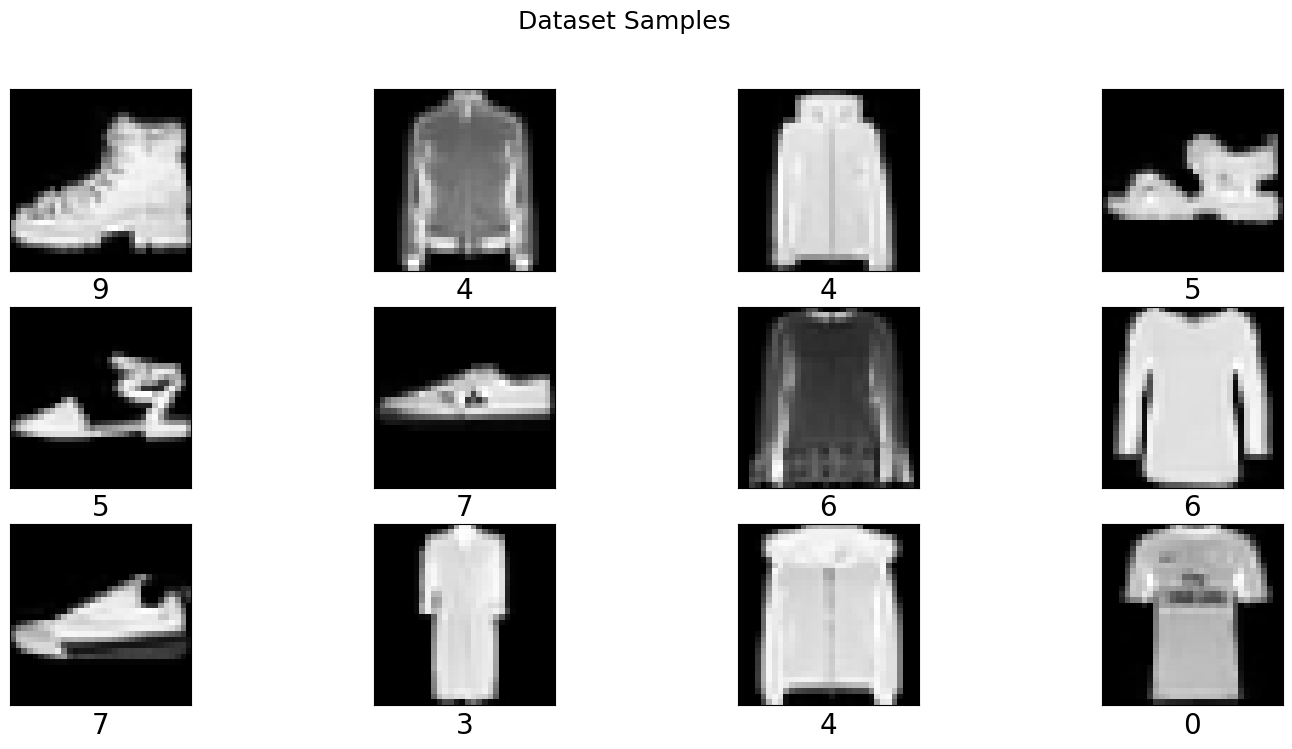

In [8]:
train_dataloader, valid_dataloader = get_data(
    resize_dimensions=(DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH),
    batch_size=TrainingConfig.BATCH_SIZE,
    dataset_mean=DatasetConfig.MEAN,
    dataset_std=DatasetConfig.STD,
)

visualise_samples(train_dataloader)

## LeNet5 Model

In [9]:
class LeNet5(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = 10):
        super().__init__()

        self._body = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=6, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )

        self._head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=16 * 5 * 5, out_features=120),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=84, out_features=num_classes),
        )

    def forward(self, x):
        x = self._body(x)
        x = self._head(x)
        return x

In [10]:
model = LeNet5(
    in_channels=DatasetConfig.IMG_CHANNELS, num_classes=DatasetConfig.NUM_CLASSES
)

summary(
    model=model,
    input_size=(
        1,
        DatasetConfig.IMG_CHANNELS,
        DatasetConfig.IMG_HEIGHT,
        DatasetConfig.IMG_WIDTH,
    ),
)

Layer (type:depth-idx)                   Output Shape              Param #
LeNet5                                   [1, 10]                   --
├─Sequential: 1-1                        [1, 16, 5, 5]             --
│    └─Conv2d: 2-1                       [1, 6, 28, 28]            156
│    └─ReLU: 2-2                         [1, 6, 28, 28]            --
│    └─MaxPool2d: 2-3                    [1, 6, 14, 14]            --
│    └─Conv2d: 2-4                       [1, 16, 10, 10]           2,416
│    └─ReLU: 2-5                         [1, 16, 10, 10]           --
│    └─MaxPool2d: 2-6                    [1, 16, 5, 5]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-7                      [1, 400]                  --
│    └─Linear: 2-8                       [1, 120]                  48,120
│    └─ReLU: 2-9                         [1, 120]                  --
│    └─Linear: 2-10                      [1, 84]                   10,164
│  

## Traning and Validation Helper functions

In [11]:
def train(
    model: nn.Module,
    optimiser: optim.Optimizer,
    train_dataloader: DataLoader,
    device: torch.device,
    num_classes: int,
    epoch_idx: int,
    total_epochs: int,
    scheduler: optim.lr_scheduler = None,
):
    model.train()

    loss_record = MeanMetric()
    accuracy_record = MulticlassAccuracy(num_classes=num_classes, average="micro")

    loader_len = len(train_dataloader)

    with tqdm(total=loader_len, ncols=122, ascii=True) as tq:
        tq.set_description(f"Train :: Epoch: {epoch_idx}/{total_epochs}")

        for data, target in train_dataloader:
            tq.update(1)

            data = data.to(device)
            target = target.to(device)

            # As all model parameters were passed during optimiser
            # initialisations, they all belong to param_group[0].
            lr = optimiser.param_groups[0]["lr"]

            optimiser.zero_grad()
            logits = model(data)

            loss = F.cross_entropy(logits, target)
            loss.backward()

            optimiser.step()

            if scheduler:
                scheduler.step()

            loss_record.update(loss.detach().cpu(), weight=data.shape[0])
            predictions = torch.argmax(logits, dim=1)

            accuracy_record.update(predictions.cpu(), target.cpu())

            tq.set_postfix_str(
                s=f"LR: {lr} Loss: {loss_record.compute():.4f} Acc: {accuracy_record.compute():.4f}"
            )

    epoch_loss = loss_record.compute()
    epoch_accuracy = accuracy_record.compute()

    return epoch_loss.item(), epoch_accuracy.item()

In [12]:
def validate(
    model: nn.Module,
    valid_dataloader: DataLoader,
    device: torch.device,
    num_classes: int,
    epoch_idx: int,
    total_epochs: int,
):
    model.eval()

    loss_record = MeanMetric()
    accuracy_record = MulticlassAccuracy(num_classes=num_classes, average="micro")

    with tqdm(total=len(valid_dataloader), ncols=122, ascii=True) as tq:
        tq.set_description(f"Valid :: Epoch: {epoch_idx}/{total_epochs}")

        for data, target in valid_dataloader:
            tq.update(1)

            data.to(device)
            target.to(device)

            with torch.no_grad():
                logits = model(data)

            loss = F.cross_entropy(logits, target)
            loss_record.update(loss.cpu(), weight=data.shape[0])

            predictions = torch.argmax(logits, dim=1)
            accuracy_record.update(predictions.cpu(), target.cpu())

        epoch_loss = loss_record.compute()
        epoch_accuracy = accuracy_record.compute()

        tq.set_postfix_str(f"Loss: {epoch_loss:.4f} Acc:{epoch_accuracy:.4f}")

    return epoch_loss.item(), epoch_accuracy.item()

## Training function for the Model

In [13]:
def main(
    model: nn.Module,
    optimiser: optim.Optimizer,
    device: torch.device,
    pin_memory: bool = False,
    scheduler_dict=None,
):
    train_dataloader, valid_dataloader = get_data(
        resize_dimensions=(DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH),
        batch_size=TrainingConfig.BATCH_SIZE,
        dataset_mean=DatasetConfig.MEAN,
        dataset_std=DatasetConfig.STD,
        pin_memory=pin_memory,
        data_root=DatasetConfig.DATA_ROOT,
        num_workers=TrainingConfig.NUM_WORKERS,
    )

    epoch_train_loss = []
    epoch_train_accuracy = []
    epoch_valid_loss = []
    epoch_valid_accuracy = []

    total_epochs = TrainingConfig.NUM_EPOCHS

    if scheduler_dict:
        scheduler = scheduler_dict["scheduler"]
        update_per_epoch = scheduler_dict["update_per_epoch"]
    else:
        scheduler = None
        update_per_epoch = False

    # model = torch.compile(model)

    for epoch in range(total_epochs):
        train_loss, train_accuracy = train(
            model=model,
            optimiser=optimiser,
            train_dataloader=train_dataloader,
            device=device,
            num_classes=DatasetConfig.NUM_CLASSES,
            epoch_idx=epoch + 1,
            total_epochs=total_epochs,
            scheduler=None if update_per_epoch else scheduler,
        )
        valid_loss, valid_accuracy = validate(
            model=model,
            valid_dataloader=valid_dataloader,
            device=device,
            num_classes=DatasetConfig.NUM_CLASSES,
            epoch_idx=epoch + 1,
            total_epochs=total_epochs,
        )

        epoch_train_loss.append(train_loss)
        epoch_train_accuracy.append(train_accuracy)
        epoch_valid_loss.append(valid_loss)
        epoch_valid_accuracy.append(valid_accuracy)

        if scheduler and update_per_epoch:
            scheduler.step()

    del model
    del optimiser
    del train_dataloader
    del valid_dataloader

    gc.collect()
    torch.cuda.empty_cache()

    return (
        epoch_train_loss,
        epoch_train_accuracy,
        epoch_valid_loss,
        epoch_valid_accuracy,
    )

In [14]:
def initialise_model_optimiser(device: torch.device, momentum: float = 0.9):
    seed_everything(seed_value=41)

    model = LeNet5(
        in_channels=DatasetConfig.IMG_CHANNELS, num_classes=DatasetConfig.NUM_CLASSES
    )
    model.to(device)

    optimiser = optim.SGD(
        model.parameters(), lr=TrainingConfig.LEARNING_RATE, momentum=momentum
    )

    return model, optimiser

## SGD Momentum without LR Scheduler

In [ ]:
# Get available accelearation device.
DEVICE, GPU_AVAILABLE = get_default_device()

# Get Model and Optimizer.
model, optimizer = initialise_model_optimiser(DEVICE, momentum=0.9)

# Start Training.
# TODO: Make sure to change the variable names to `main` returns loss, accuracy, loss, accuracy
train_acc, train_loss, valid_acc, valid_loss = main(
    model=model,
    optimiser=optimizer,
    device=DEVICE,
    pin_memory=GPU_AVAILABLE,
    scheduler_dict=None,
)

Valid :: Epoch: 61/61: 100%|#####################################| 79/79 [00:02<00:00, 27.63it/s, Loss: 0.2228 Acc:0.9228]


## Training with LR Scheduler - Exponential Decay

$$
\normalsize{\alpha = \alpha_0 * \gamma^n}
$$

where:

$\alpha_0$ = initial learning rate

$n$ = epoch

$\gamma$ = decay rate

### Plotting LR curve using dummy data

In [16]:
dummy_model = nn.Linear(in_features=3, out_features=2)

dummy_optimiser = optim.SGD(
    model.parameters(), lr=TrainingConfig.LEARNING_RATE, momentum=0.9
)


def plot_lr_using_dummy_data(
    scheduler: lr_scheduler,
    plot_title: str = "LR Scheduler",
):
    learn_rate_record = []
    for i in range(TrainingConfig.NUM_EPOCHS):
        learn_rate_record.append(scheduler.get_last_lr()[-1])
        scheduler.step()

    plt.plot(learn_rate_record)
    plt.grid(True)
    plt.title(plot_title)
    plt.xlabel("Epochs")
    plt.ylabel("Learning Rate")
    plt.show()

    print(f"First LR: {learn_rate_record[0]} Last: {learn_rate_record[-1]}")

/Users/tapasyagutta/workspace/deep-learning/.pytorchVEnv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


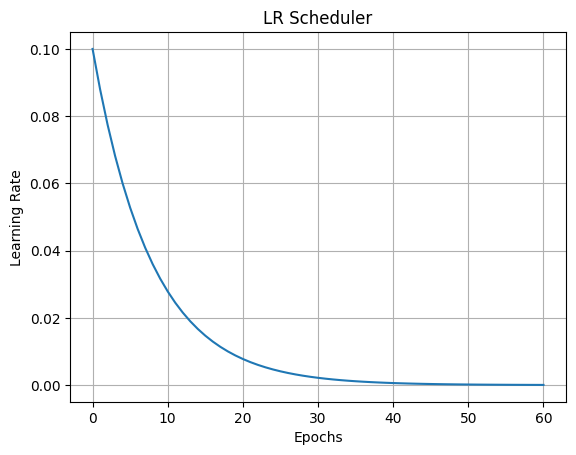

First LR: 0.1 Last: 4.666167548727584e-05


In [17]:
plot_lr_using_dummy_data(
    scheduler=lr_scheduler.ExponentialLR(dummy_optimiser, gamma=0.88)
)

### FashionMNIST Data

In [18]:
# Get available accelearation device.
DEVICE, GPU_AVAILABLE = get_default_device()

# Get Model and Optimizer.
model, optimizer = initialise_model_optimiser(DEVICE, momentum=0.9)

scheduler_dict = {
    "scheduler": lr_scheduler.ExponentialLR(optimizer, gamma=0.88),
    "update_per_epoch": True,
}

# Start Training.
ed_train_acc, ed_train_loss, ed_valid_acc, ed_valid_loss = main(
    model=model,
    optimiser=optimizer,
    device=DEVICE,
    pin_memory=GPU_AVAILABLE,
    scheduler_dict=scheduler_dict,
)

Valid :: Epoch: 61/61: 100%|#####################################| 79/79 [00:03<00:00, 25.06it/s, Loss: 0.1397 Acc:0.9544]


## Training with LR Scheduler - Multi-Step LR

1. A multi-step learning rate scheduler divides the training process into multiple steps and allows for making learning rate adjustments at predefined milestones or steps during the training process.

2. Typically, the learning rate is decreased at specific epochs or after a certain number of iterations or a milestone is reached. 

3. By using a multi-step learning rate scheduler, you have more control over the learning rate throughout the training process.

### Dummy Data

/Users/tapasyagutta/workspace/deep-learning/.pytorchVEnv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


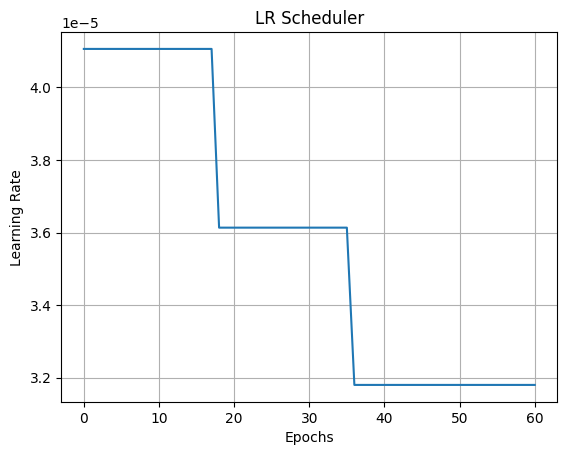

First LR: 4.106227442880274e-05 Last: 3.1798625317664846e-05


In [ ]:
plot_lr_using_dummy_data(
    scheduler=lr_scheduler.MultiStepLR(dummy_optimiser, milestones =[18, 36], gamma=0.1)
)

### FashionMNIST

In [22]:
# Get available accelearation device.
DEVICE, GPU_AVAILABLE = get_default_device()

# Get Model and Optimizer.
model, optimizer = initialise_model_optimiser(DEVICE, momentum=0.9)

scheduler_dict = {
    "scheduler": lr_scheduler.MultiStepLR(optimizer, milestones=[18, 36], gamma=0.1),
    "update_per_epoch": True,
}

# Start Training.
ms_train_acc, ms_train_loss, ms_valid_acc, ms_valid_loss = main(
    model=model,
    optimiser=optimizer,
    device=DEVICE,
    pin_memory=GPU_AVAILABLE,
    scheduler_dict=scheduler_dict,
)

Valid :: Epoch: 61/61: 100%|#####################################| 79/79 [00:03<00:00, 25.80it/s, Loss: 0.1167 Acc:0.9607]


## Training with LR Scheduler - OneCycle LR

1. The OneCycle learning rate scheduler is a technique to dynamically adjust the learning rate during training. It is based on the idea of using cyclical learning rates, where the learning rate varies between a minimum value and a maximum value within a single cycle.

2. The OneCycle learning rate scheduler adjusts the learning rate based on a cyclical schedule, typically consisting of three phases:

   1. Increasing the learning rate
   2. Decreasing the learning rate
   3. Then further decreasing it towards the end of training. 
  
3. This cycling behavior is designed to help the model explore different regions of the loss landscape and converge faster.

### Dummy Data

/Users/tapasyagutta/workspace/deep-learning/.pytorchVEnv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


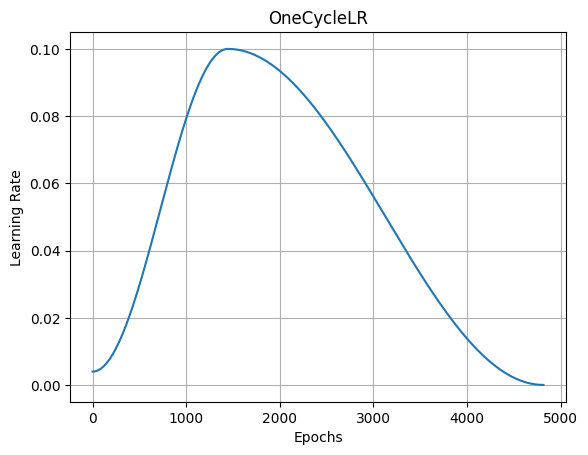

First LR: 0.0040000000000000036 Last: 4e-05


In [26]:
# Calculate total training steps.
steps_per_epoch = len(train_dataloader)  # Number of batches.
total_training_steps = TrainingConfig.NUM_EPOCHS * steps_per_epoch

scheduler = lr_scheduler.OneCycleLR(
    dummy_optimiser,
    max_lr=TrainingConfig.LEARNING_RATE,
    total_steps=total_training_steps,
    final_div_factor=1e2,
)

learn_rate_record = []
for epoch in range(TrainingConfig.NUM_EPOCHS):
    for _ in range(steps_per_epoch):
        learn_rate_record.append(
            scheduler.get_last_lr()[-1]
        )  # Get Current LR used for parameter updates.

        # optimizer.step()
        scheduler.step()  # Update Learning Rate

plt.plot(learn_rate_record)
plt.grid(True)
plt.title("OneCycleLR")
plt.xlabel("Epochs")
plt.ylabel("Learning Rate")
plt.show()

print(f"First LR: {learn_rate_record[0]} Last: {learn_rate_record[-1]}")

### FashionMNIST

In [24]:
# Get available accelearation device.
DEVICE, GPU_AVAILABLE = get_default_device()

# Get Model and Optimizer.
model, optimizer = initialise_model_optimiser(DEVICE, momentum=0.9)

scheduler_dict = {
    "scheduler": lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=TrainingConfig.LEARNING_RATE,
        total_steps=total_training_steps,
        final_div_factor=1e2,
    ),
    "update_per_epoch": True,
}

# Start Training.
oc_train_acc, oc_train_loss, oc_valid_acc, oc_valid_loss = main(
    model=model,
    optimiser=optimizer,
    device=DEVICE,
    pin_memory=GPU_AVAILABLE,
    scheduler_dict=scheduler_dict,
)

Valid :: Epoch: 61/61: 100%|#####################################| 79/79 [00:02<00:00, 27.07it/s, Loss: 0.0801 Acc:0.9735]


## Training with LR Scheduler - CosineAnnealingWarmRestarts

`CosineAnnealingWarmRestarts` is a learning rate scheduler based on the idea of "cosine annealing", where the learning rate decreases according to a cosine function, but instead of doing this once, it does it in a series of cycles. This means that the learning rate starts high, decreases over time, then restarts at a high value again, over and over. 

The "Warm Restarts" part means that the learning rate doesn't just suddenly jump back to a high value, but it's adjusted smoothly. The idea is to restart the learning rate periodically, allowing the model to explore the parameter space more thoroughly and potentially find better solutions. This technique can help in finding global optima by escaping local optima, and it can also lead to faster convergence.

### Dummy Data

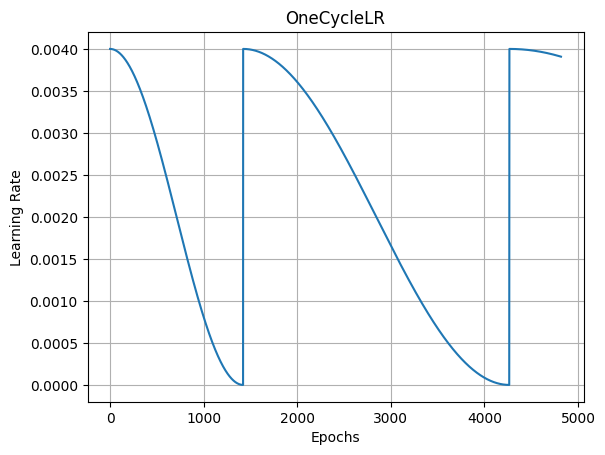

First LR: 0.004 Last: 0.0039077680876809


In [27]:
# Calculate total training steps.
steps_per_epoch = len(train_dataloader)  # Number of batches.
# First restart at the end of 18th epoch.
t_0 = steps_per_epoch * 18  # We can also set it to restart after some specified steps.
t_mult = 2

# Initialize dummy learning rate scheduler.
scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
    dummy_optimiser,
    T_0=t_0,
    T_mult=t_mult,
    eta_min=1e-7,
)

learn_rate_record = []
for epoch in range(TrainingConfig.NUM_EPOCHS):
    for _ in range(steps_per_epoch):
        learn_rate_record.append(
            scheduler.get_last_lr()[-1]
        )  # Get Current LR used for parameter updates.

        # optimizer.step()
        scheduler.step()  # Update Learning Rate

plt.plot(learn_rate_record)
plt.grid(True)
plt.title("OneCycleLR")
plt.xlabel("Epochs")
plt.ylabel("Learning Rate")
plt.show()

print(f"First LR: {learn_rate_record[0]} Last: {learn_rate_record[-1]}")

### FashionMNIST

In [28]:
# Get available accelearation device.
DEVICE, GPU_AVAILABLE = get_default_device()

# Get Model and Optimizer.
model, optimizer = initialise_model_optimiser(DEVICE, momentum=0.9)

# Calculate total training steps.
steps_per_epoch = len(train_dataloader)  # Number of batches.
# First restart at the end of 18th epoch.
t_0 = steps_per_epoch * 18  # We can also set it to restart after some specified steps.
t_mult = 2

scheduler_dict = {
    "scheduler": lr_scheduler.CosineAnnealingWarmRestarts(
        dummy_optimiser,
        T_0=t_0,
        T_mult=t_mult,
        eta_min=1e-7,
    ),
    "update_per_epoch": True,
}

# Start Training.
cw_train_acc, cw_train_loss, cw_valid_acc, cw_valid_loss = main(
    model=model,
    optimiser=optimizer,
    device=DEVICE,
    pin_memory=GPU_AVAILABLE,
    scheduler_dict=scheduler_dict,
)

Valid :: Epoch: 61/61: 100%|#####################################| 79/79 [00:02<00:00, 27.57it/s, Loss: 0.2228 Acc:0.9228]


## Plotting Accuracy and Loss Curves

In [29]:
def plot_results(metrics, ylabel=None, ylim=None, metric_name=None, color=None):
    fig, ax = plt.subplots(figsize=(18, 5))
    # ax.set_facecolor("white")

    if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):
        metrics = [
            metrics,
        ]
        metric_name = [
            metric_name,
        ]

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(ylabel + " per Epoch")
    plt.xlim([0, TrainingConfig.NUM_EPOCHS - 1])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(True)
    plt.legend(metric_name)
    plt.tight_layout()
    plt.savefig(f"{ylabel}.png")
    plt.show()
    plt.close()

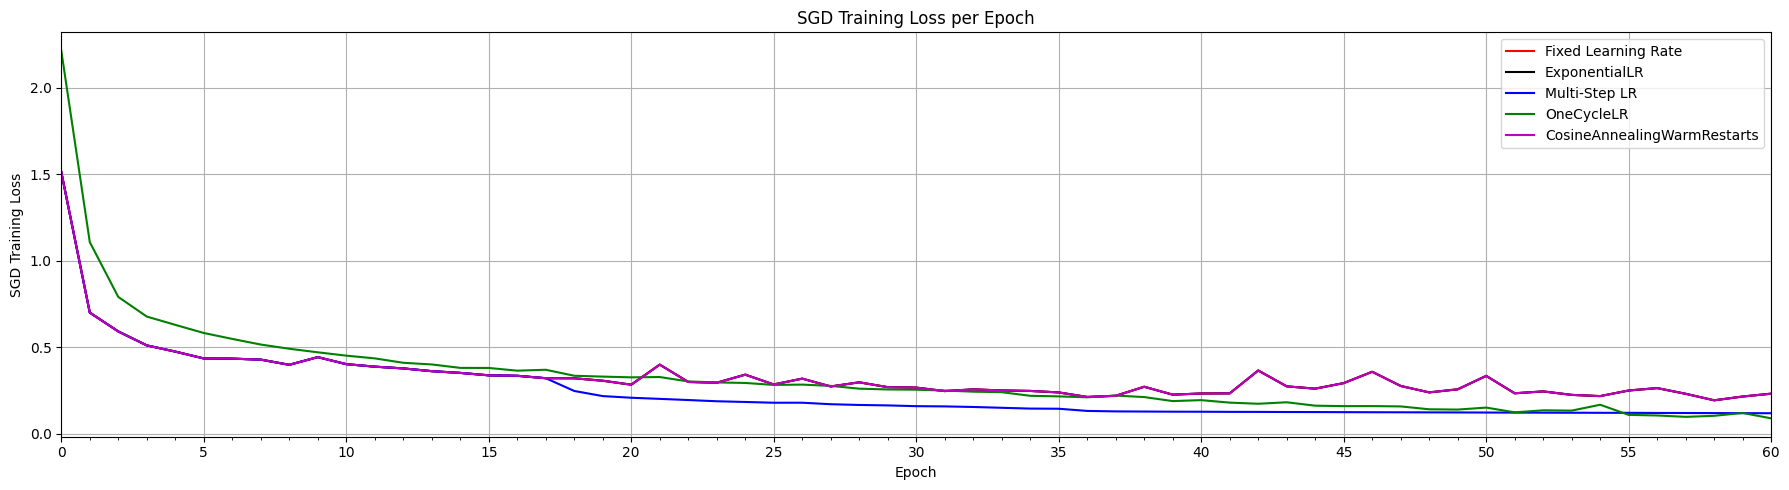

In [37]:
plot_results(
    [train_acc, train_acc, ms_train_acc, oc_train_acc, cw_train_acc],
    ylabel="SGD Training Loss",
    # ylim=[0.0, 1.2],
    metric_name=[
        "Fixed Learning Rate",
        "ExponentialLR",
        "Multi-Step LR",
        "OneCycleLR",
        "CosineAnnealingWarmRestarts",
    ],
    color=["r", "k", "b", "g", "m"],
)

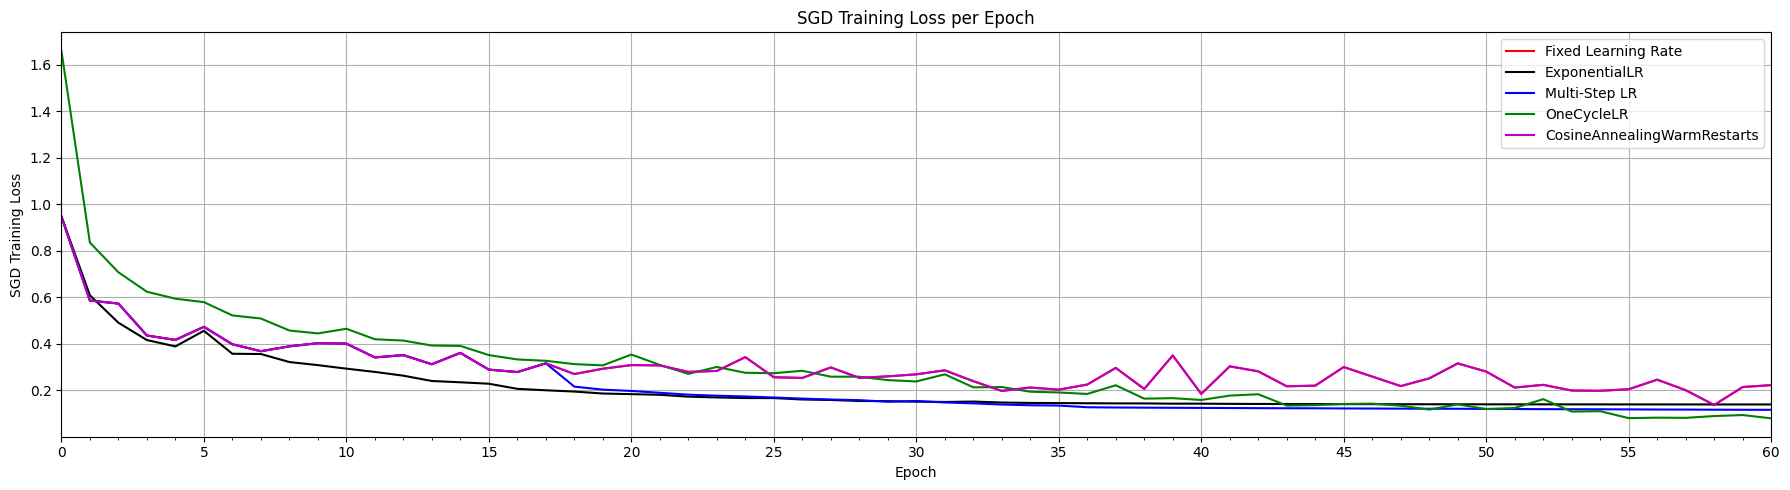

In [38]:
plot_results(
    [valid_acc, ed_valid_acc, ms_valid_acc, oc_valid_acc, cw_valid_acc],
    ylabel="SGD Training Loss",
    # ylim=[0.0, 1.2],
    metric_name=[
        "Fixed Learning Rate",
        "ExponentialLR",
        "Multi-Step LR",
        "OneCycleLR",
        "CosineAnnealingWarmRestarts",
    ],
    color=["r", "k", "b", "g", "m"],
)